In [1]:
import cv2
import os
import numpy as np
from PIL import Image  # Untuk menangani file yang tidak terbaca oleh OpenCV

# Path folder dataset
folder = r'E:\Project Besar\DS-2'

# Memeriksa apakah folder ada
if not os.path.exists(folder):
    print(f"Folder {folder} tidak ditemukan!")
    exit()

# Membaca file gambar (termasuk .jpg dan .png)
image_files = [f for f in os.listdir(folder) if f.lower().endswith(('.jpg', '.png'))]

# Menampilkan jumlah file yang ditemukan
print(f'Jumlah file gambar yang ditemukan: {len(image_files)}')

Jumlah file gambar yang ditemukan: 8550


In [2]:
X = []  # Data gambar
y = []  # Label gambar

# Membaca dan memproses setiap gambar
for filename in image_files:
    image_path = os.path.join(folder, filename)

    # Coba membaca gambar dengan OpenCV
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    # Jika gambar tidak dapat dibaca oleh OpenCV, gunakan Pillow sebagai cadangan
    if img is None:
        try:
            img_pillow = Image.open(image_path).convert('L')  # Konversi ke grayscale
            img = np.array(img_pillow)  # Konversi gambar ke array NumPy
            print(f"Gambar berhasil dimuat dengan Pillow: {filename}")
        except Exception as e:
            print(f"Gambar tidak dapat dimuat: {filename}, Error: {e}")
            continue

    # Resize gambar menjadi 64x64
    img_resized = cv2.resize(img, (128, 128))
    X.append(img_resized)

    # Ambil label dari nama file (misalnya, angka sebelum underscore "_")
    try:
        label = int(filename.split('_')[0])
        y.append(label)
    except ValueError:
        print(f"Format nama file tidak sesuai: {filename}")
        continue

# Konversi data dan label menjadi array NumPy
X = np.array(X)
y = np.array(y)

print(f"Jumlah gambar yang diproses: {len(X)}")
print(f"Jumlah label yang diproses: {len(y)}")

Gambar berhasil dimuat dengan Pillow: 6_C_6301102009010_2_6.jpg
Jumlah gambar yang diproses: 8550
Jumlah label yang diproses: 8550


pembagian dataset

In [3]:
from sklearn.model_selection import train_test_split

# Membagi data menjadi training dan testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

algoritma svm

In [ ]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Reshape data 3D menjadi 2D
n_samples = X_train.shape[0]
X_train_reshaped = X_train.reshape(n_samples, -1)
X_test_reshaped = X_test.reshape(X_test.shape[0], -1)

# Normalisasi data menggunakan StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_reshaped)
X_test_scaled = scaler.transform(X_test_reshaped)


# Membuat model SVM dengan kernel linear
clf = SVC(kernel='linear', random_state=42)

# Melatih model dengan data latih yang sudah dinormalisasi
clf.fit(X_train_scaled, y_train)

# Membuat prediksi pada data test
y_pred = clf.predict(X_test_scaled)


# Menghitung akurasi model
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Model SVM selesai dilatih!")
# Menampilkan laporan klasifikasi
print(f"Akurasi model: {accuracy * 100:.2f}%")
print(classification_report(y_test, y_pred))


cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

algoritma knn

Model KNN selesai dilatih!
Akurasi model: 55.44%
              precision    recall  f1-score   support

           0       0.75      0.76      0.76       211
           1       0.52      0.97      0.68       239
           2       0.55      0.60      0.58       212
           3       0.37      0.54      0.44       162
           4       0.68      0.62      0.65       165
           5       0.50      0.48      0.49       162
           6       0.58      0.32      0.41       155
           7       0.71      0.46      0.56       142
           8       0.47      0.16      0.24       133
           9       0.44      0.19      0.26       129

    accuracy                           0.55      1710
   macro avg       0.56      0.51      0.51      1710
weighted avg       0.56      0.55      0.53      1710



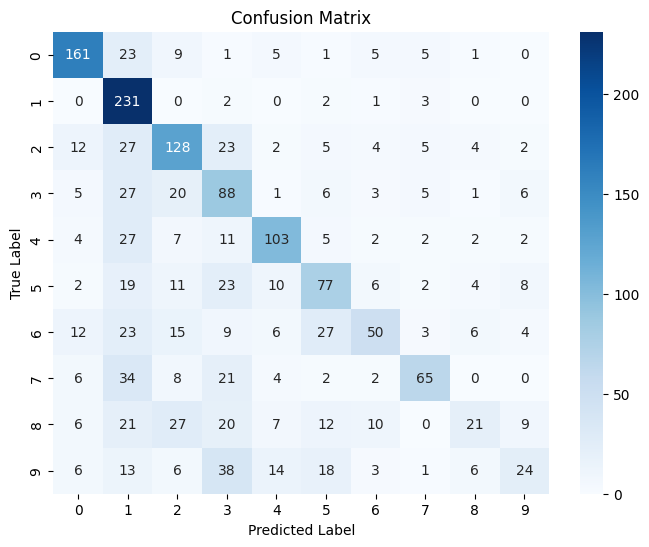

In [8]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Reshape data 3D menjadi 2D
n_samples = X_train.shape[0]
X_train_reshaped = X_train.reshape(n_samples, -1)
X_test_reshaped = X_test.reshape(X_test.shape[0], -1)

# Normalisasi data menggunakan StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_reshaped)
X_test_scaled = scaler.transform(X_test_reshaped)



# Membuat model KNN dengan k=3 (atau sesuai kebutuhan)
k = 10  # Anda bisa mencoba berbagai nilai k untuk mencari yang terbaik
knn = KNeighborsClassifier(n_neighbors=k)

# Melatih model dengan data latih yang sudah dinormalisasi
knn.fit(X_train_scaled, y_train)

# Membuat prediksi pada data test
y_pred = knn.predict(X_test_scaled)

# Menghitung akurasi model
accuracy = accuracy_score(y_test, y_pred)

print("Model KNN selesai dilatih!")
print(f"Akurasi model: {accuracy * 100:.2f}%")

# Menampilkan laporan klasifikasi
print(classification_report(y_test, y_pred))

# Membuat confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

agoritma random forest

Model Random Forest selesai dilatih!
Akurasi model: 88.07%
              precision    recall  f1-score   support

           0       0.89      0.93      0.91       211
           1       0.93      0.97      0.95       239
           2       0.88      0.88      0.88       212
           3       0.75      0.94      0.83       162
           4       0.89      0.94      0.91       165
           5       0.89      0.85      0.87       162
           6       0.88      0.89      0.88       155
           7       0.92      0.89      0.90       142
           8       0.93      0.67      0.78       133
           9       0.88      0.73      0.80       129

    accuracy                           0.88      1710
   macro avg       0.88      0.87      0.87      1710
weighted avg       0.88      0.88      0.88      1710



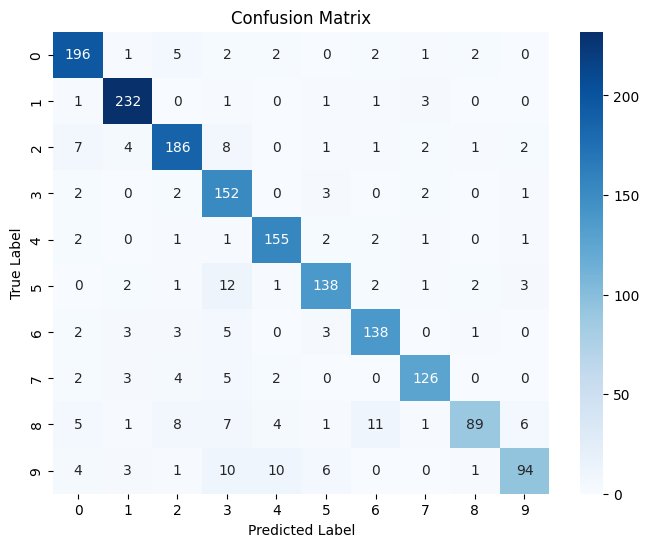

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Reshape data 3D menjadi 2D
n_samples = X_train.shape[0]
X_train_reshaped = X_train.reshape(n_samples, -1)
X_test_reshaped = X_test.reshape(X_test.shape[0], -1)

# Normalisasi data menggunakan StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_reshaped)
X_test_scaled = scaler.transform(X_test_reshaped)



# Membuat model Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)  # Anda dapat menyesuaikan parameter seperti n_estimators

# Melatih model dengan data latih yang sudah dinormalisasi
rf.fit(X_train_scaled, y_train)

# Membuat prediksi pada data test
y_pred = rf.predict(X_test_scaled)

# Menghitung akurasi model
accuracy = accuracy_score(y_test, y_pred)

print("Model Random Forest selesai dilatih!")
print(f"Akurasi model: {accuracy * 100:.2f}%")

# Menampilkan laporan klasifikasi
print(classification_report(y_test, y_pred))

# Membuat confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()
